In [1]:
import numpy as np
from mesoscopy.resources import get_atlas, get_atlas_annotations
import matplotlib.pyplot as plt
from mesoscopy import io
from mesoscopy.process import region


In [2]:
f = io.read_h5("../scratch/sub-test_exp-testexp_meso_date-2025-05-20T14_42_39_preprocessed_registered.h5")

In [3]:
l_aba, r_aba = get_atlas()

In [4]:
l_aba

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(140, 142), dtype=uint16)

In [5]:
mask = np.broadcast_to(l_aba == 578, f["F"].shape)

np.ma.array(f["F"], mask=~mask)

masked_array(
  data=[[[--, --, --, ..., --, --, --],
         [--, --, --, ..., --, --, --],
         [--, --, --, ..., --, --, --],
         ...,
         [--, --, --, ..., --, --, --],
         [--, --, --, ..., --, --, --],
         [--, --, --, ..., --, --, --]],

        [[--, --, --, ..., --, --, --],
         [--, --, --, ..., --, --, --],
         [--, --, --, ..., --, --, --],
         ...,
         [--, --, --, ..., --, --, --],
         [--, --, --, ..., --, --, --],
         [--, --, --, ..., --, --, --]],

        [[--, --, --, ..., --, --, --],
         [--, --, --, ..., --, --, --],
         [--, --, --, ..., --, --, --],
         ...,
         [--, --, --, ..., --, --, --],
         [--, --, --, ..., --, --, --],
         [--, --, --, ..., --, --, --]],

        ...,

        [[--, --, --, ..., --, --, --],
         [--, --, --, ..., --, --, --],
         [--, --, --, ..., --, --, --],
         ...,
         [--, --, --, ..., --, --, --],
         [--, --, --, ..., --,

In [6]:
annotations = get_atlas_annotations()
annotations

,id,acronym,name
0,11,SSp-ul,Primary somatosensory area upper limb
1,97,AUDd1,Dorsal auditory area
2,104,AUDp1,Primary auditory area
3,111,AUDpo1,Posterior auditory area
4,118,AUDv1,Ventral auditory area
5,395,FRP1,Frontal pole
6,578,MOp1,Primary motor area
7,584,MOs,Secondary motor area
8,665,ORBm1,Orbital area medial part
9,753,PL1,Prelimbic area


In [7]:
annotations.loc[annotations["acronym"] == "VISli1", "id"].values[0]

np.int64(1214)

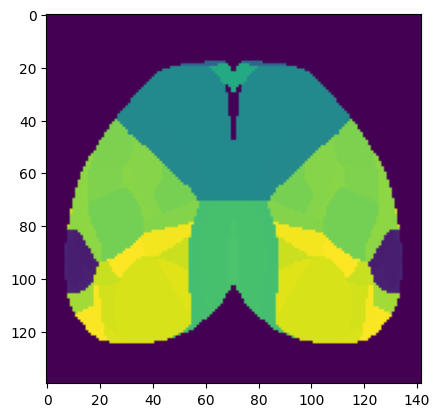

In [8]:
plt.imshow(l_aba + r_aba)

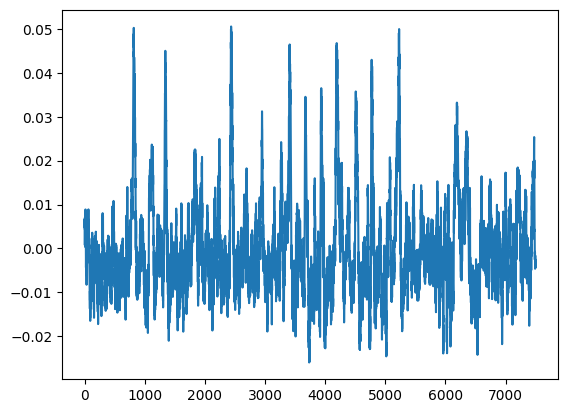

In [9]:
plt.plot(np.ma.array(f["F"], mask=~mask).mean(axis=(1, 2)))

In [10]:
get_atlas_annotations().acronym.unique()

array(['SSp-ul', 'AUDd1', 'AUDp1', 'AUDpo1', 'AUDv1', 'FRP1', 'MOp1',
       'MOs', 'ORBm1', 'PL1', 'RSPagl1', 'RSPd1', 'RSPv1', 'SSp-bfd1',
       'SSp-ll1', 'SSp-m1', 'SSp-n1', 'SSp-tr1', 'SSp-ul1', 'SSp-un1',
       'SSs1', 'TEa1', 'VISal1', 'VISam1', 'VISC1', 'VISl1', 'VISp',
       'VISpl1', 'VISpm', 'VISa1', 'VISli1', 'VISpor1', 'VISrl1'],
      dtype=object)

In [11]:
region_activity = region.extract_all_regions(deltaf_series=f["F"])

In [12]:
region_activity

{'L_SSp-ul': masked_array(data=[-0.00604184390977025, -0.01060702744871378,
                    -0.008824565447866917, ..., -4.267902113497257e-05,
                    -0.006469919346272945, 0.0030176336877048016],
              mask=[False, False, False, ..., False, False, False],
        fill_value=1e+20),
 'R_SSp-ul': masked_array(data=[-0.009447815828025341, -0.001017036847770214,
                    -0.0046899644657969475, ..., -0.0026234539691358805,
                    0.0009041279554367065, -0.000360634527169168],
              mask=[False, False, False, ..., False, False, False],
        fill_value=1e+20),
 'L_MOp1': masked_array(data=[0.0009656610160038389, 0.006643298028529376,
                    0.004778639110112099, ..., -0.0031457458876101908,
                    -0.004371119641709602, -0.0018309765848620184],
              mask=[False, False, False, ..., False, False, False],
        fill_value=1e+20),
 'R_MOp1': masked_array(data=[-0.0013334494212578084, 0.002011706545

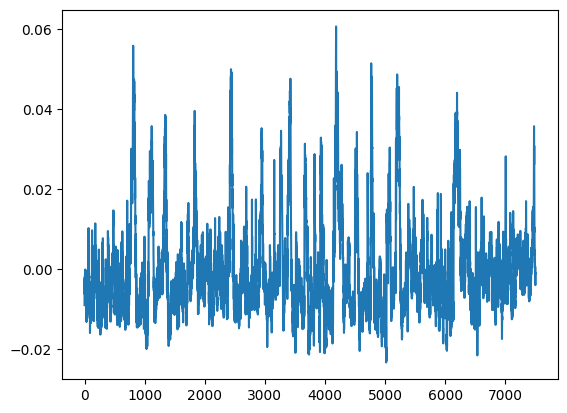

In [13]:
plt.plot(region_activity["L_MOs"])

In [15]:
region.extract_all_regions(deltaf_series=f["F"], exclude=["VISrl1"])

{'L_SSp-ul': masked_array(data=[-0.00604184390977025, -0.01060702744871378,
                    -0.008824565447866917, ..., -4.267902113497257e-05,
                    -0.006469919346272945, 0.0030176336877048016],
              mask=[False, False, False, ..., False, False, False],
        fill_value=1e+20),
 'R_SSp-ul': masked_array(data=[-0.009447815828025341, -0.001017036847770214,
                    -0.0046899644657969475, ..., -0.0026234539691358805,
                    0.0009041279554367065, -0.000360634527169168],
              mask=[False, False, False, ..., False, False, False],
        fill_value=1e+20),
 'L_MOp1': masked_array(data=[0.0009656610160038389, 0.006643298028529376,
                    0.004778639110112099, ..., -0.0031457458876101908,
                    -0.004371119641709602, -0.0018309765848620184],
              mask=[False, False, False, ..., False, False, False],
        fill_value=1e+20),
 'R_MOp1': masked_array(data=[-0.0013334494212578084, 0.002011706545